# Final assignment BID Data Analysis
Miłosz Sarnik

## Exercise 1.1

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, StratifiedKFold, cross_validate, train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score

from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt
from statsmodels.tsa.arima.model import ARIMA

sns.set(style='whitegrid', context='notebook')

DATA_PATH = 'amsterdam.csv'
TIME_PATH = 'timeline_housing_price_amsterdam.csv'

df = pd.read_csv(DATA_PATH, sep=';')
for c in ['price','area','volume','floors','year_build','has_garden','photos','rooms']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

for c in ['lat','lng']:
    s = df[c].astype(str).str.replace('.', '', regex=False)
    df[c] = pd.to_numeric(s, errors='coerce') / 1_000_000

pc4 = df['postalcode'].astype(str).str.extract(r'^(\d{4})')[0]
df['postcode4'] = pd.to_numeric(pc4, errors='coerce')

def map_area(pc):
    if pd.isna(pc):
        return np.nan
    pc = int(pc)
    if 1011 <= pc <= 1019:
        return 'Centrum'
    if 1020 <= pc <= 1039:
        return 'Noord'
    if 1040 <= pc <= 1047:
        return 'Westpoort'
    if 1050 <= pc <= 1059:
        return 'West'
    if 1060 <= pc <= 1069:
        return 'Nieuw-West'
    if 1070 <= pc <= 1083:
        return 'Zuid'
    if 1084 <= pc <= 1098:
        return 'Oost'
    if 1100 <= pc <= 1109:
        return 'Zuidoost'
    return 'Other'

df['stadsdeel'] = df['postcode4'].map(map_area)

df.head()

,postalcode,street,lat,lng,price,area,volume,floors,year_build,has_garden,type,photos,rooms,postcode4,stadsdeel
0,1015 AK Amsterdam,Langestraat 31,5.237799,4.891947,895000,164,450,4,1700,0,woonhuis,42,5,1015,Centrum
1,1018 LZ Amsterdam,Kleine Wittenburgerstraat 124,5.237103,4.921513,275000,56,189,1,1981,0,appartement,27,2,1018,Centrum
2,1073 TB Amsterdam,Karel du Jardinstraat 53 HS+PP,5.235155,4.895647,550000,83,328,1,2000,1,appartement,39,3,1073,Zuid
3,1073 XA Amsterdam,Gerard Doustraat 190 III,5.235642,0.489563,375000,69,222,1,1880,0,appartement,18,2,1073,Zuid
4,1067 MT Amsterdam,Jan van Duivenvoordestraat 137,5.237949,4.802591,249000,97,295,1,2002,0,appartement,22,4,1067,Nieuw-West


In [2]:
# 1.1 a-d: choose area/type with best modeling potential
features = ['area','volume','photos','rooms','year_build']
rows = []
for (area_name, house_type), g in df.dropna(subset=['price']).groupby(['stadsdeel', 'type']):
    if len(g) < 40:
        continue
    corrs = {f: g['price'].corr(g[f]) for f in features}
    mean_abs_corr = np.nanmean([abs(v) for v in corrs.values()])
    rows.append({
        'stadsdeel': area_name,
        'type': house_type,
        'n': len(g),
        'mean_abs_corr': mean_abs_corr,
        **corrs
    })

rank_df = pd.DataFrame(rows)
rank_df['score'] = rank_df['n'] * rank_df['mean_abs_corr']
rank_df = rank_df.sort_values(['score','n'], ascending=False)
rank_df.head(12)

,stadsdeel,type,n,mean_abs_corr,area,volume,photos,rooms,year_build,score
8,West,appartement,475,0.565689,0.887035,0.865739,0.443967,0.579646,0.052059,268.702461
9,Zuid,appartement,382,0.576270,0.898658,0.881202,0.442721,0.634926,0.023845,220.135296
0,Centrum,appartement,438,0.478773,0.846339,0.862248,0.039862,0.580263,0.065155,209.702733
2,Nieuw-West,appartement,250,0.574050,0.838261,0.775407,0.185694,0.528154,0.542735,143.512571
6,Oost,appartement,270,0.518519,0.917537,0.874454,-0.130320,0.620886,0.049396,140.000020
3,Nieuw-West,woonhuis,128,0.564444,0.882771,0.846316,0.313631,0.681369,0.098133,72.248802
10,Zuidoost,appartement,107,0.589643,0.785950,0.754769,0.298729,0.629363,0.479405,63.091825
5,Noord,woonhuis,97,0.542115,0.817950,0.772553,0.407866,0.514996,-0.197212,52.585184
4,Noord,appartement,93,0.507009,0.804577,0.788049,0.279576,0.283402,0.379439,47.151806
1,Centrum,woonhuis,67,0.624334,0.928546,0.895255,0.220585,0.777368,-0.299916,41.830374


In [3]:
# chosen segment
chosen_area = 'West'
chosen_type = 'appartement'
segment = df[(df['stadsdeel'] == chosen_area) & (df['type'] == chosen_type)].copy()
print('Chosen:', chosen_area, '-', chosen_type)
print('Rows:', len(segment))
print('Reason: largest useful sample with strong correlations for price modeling.')
print('Extra context used: postcode map (Wikipedia) + Amsterdam woningwaarde map.')

Chosen: West - appartement
Rows: 475
Reason: largest useful sample with strong correlations for price modeling.
Extra context used: postcode map (Wikipedia) + Amsterdam woningwaarde map.


In [4]:
# 1.1 e: price categories (quartiles)
q1, q2, q3 = segment['price'].quantile([0.25, 0.50, 0.75])
bins = [-np.inf, q1, q2, q3, np.inf]
labels = ['low', 'mid-low', 'mid-high', 'high']
segment['price_category'] = pd.cut(segment['price'], bins=bins, labels=labels)

print('Price cutoffs:', {'Q1': q1, 'Q2': q2, 'Q3': q3})
segment['price_category'].value_counts().sort_index()

Price cutoffs: {'Q1': 250000.0, 'Q2': 315000.0, 'Q3': 432500.0}


price_category
low         133
mid-low     107
mid-high    116
high        119
Name: count, dtype: int64

In [5]:
# 1.1 f: first intuitive model idea
candidate_vars = ['area','volume','rooms','year_build','photos','floors','has_garden']
print('Initial expected important variables:', candidate_vars)
print('Main expectation: area and volume are strongest drivers of price.')

Initial expected important variables: ['area', 'volume', 'rooms', 'year_build', 'photos', 'floors', 'has_garden']
Main expectation: area and volume are strongest drivers of price.


In [6]:
# 1.1 g: data description
print('Columns:', list(segment.columns))
print('Shape:', segment.shape)
segment.describe(include='all').T[['count']].head(20)

missing = segment.isna().sum().sort_values(ascending=False)
missing[missing > 0].head(20)

Columns: ['postalcode', 'street', 'lat', 'lng', 'price', 'area', 'volume', 'floors', 'year_build', 'has_garden', 'type', 'photos', 'rooms', 'postcode4', 'stadsdeel', 'price_category']
Shape: (475, 16)


Series([], dtype: int64)

,mean,std,min,max,range
price,384556.505263,235487.287289,0,2595000,2595000
area,73.648421,34.653568,0,249,249
volume,228.993684,116.046159,27,925,898
photos,22.863158,7.716783,1,48,47
rooms,3.000000,1.041340,1,8,7
year_build,1936.585263,37.620953,1882,2017,135


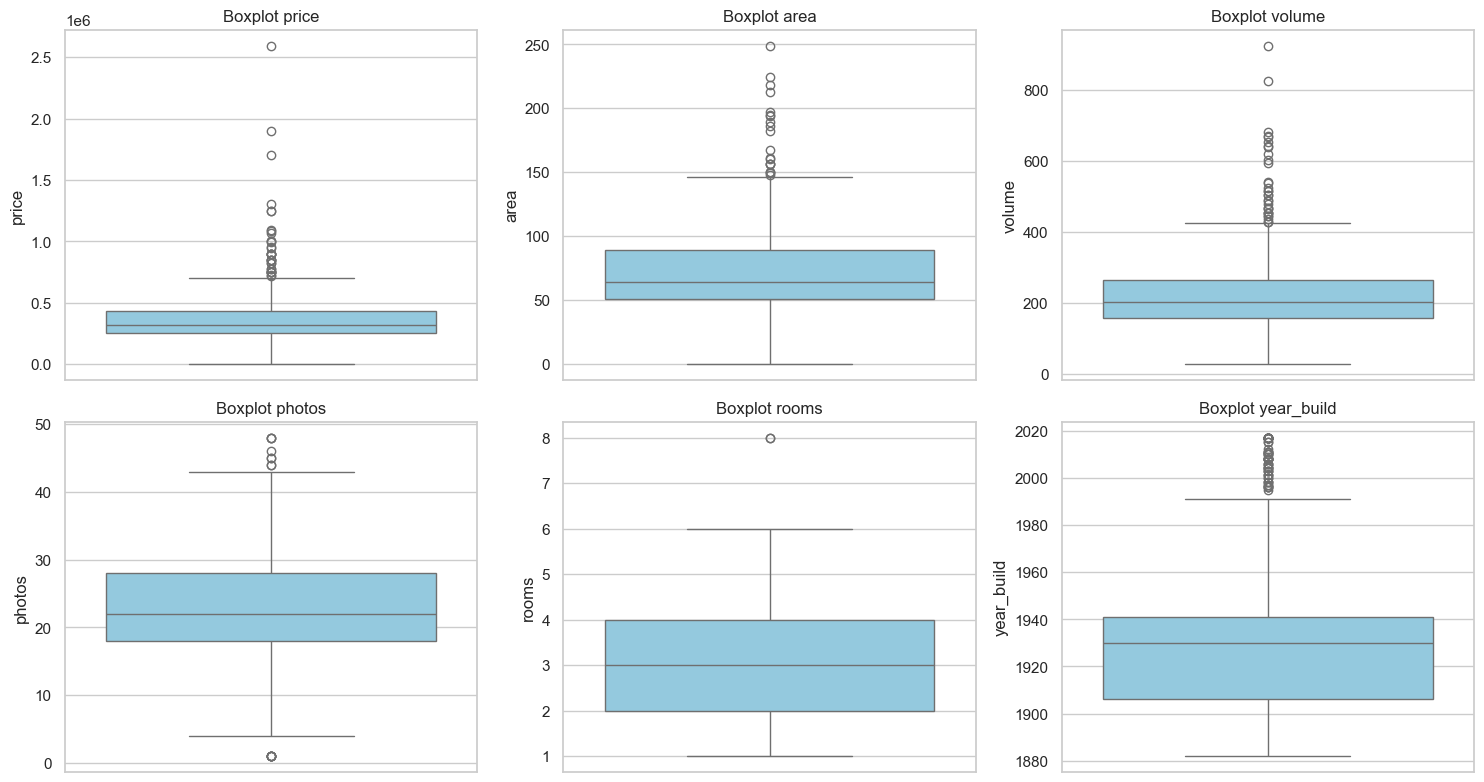

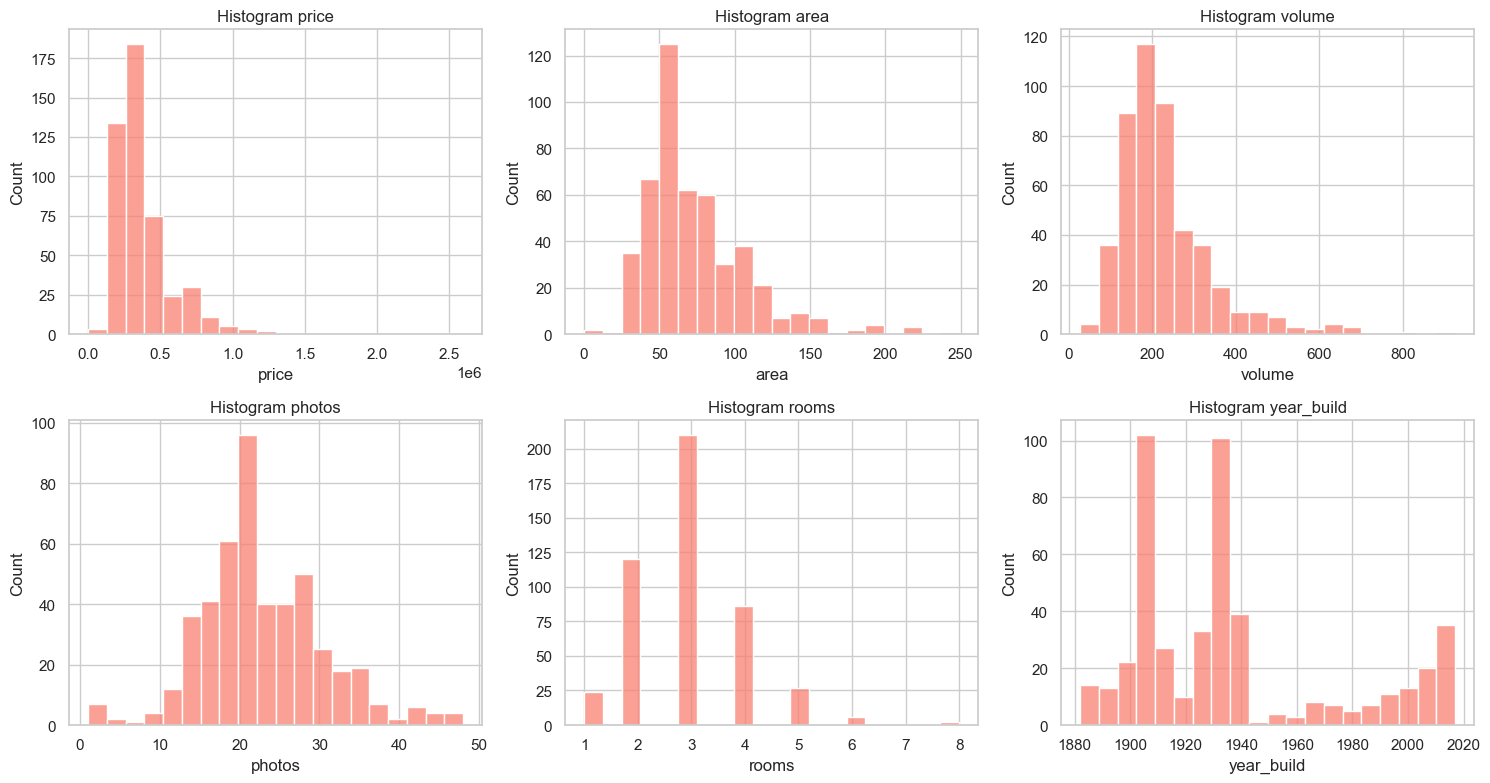

Outliers count per variable: {'price': 34, 'area': 20, 'volume': 32, 'photos': 15, 'rooms': 2, 'year_build': 73}
Conclusion: area, volume, rooms are most useful; photos and year_build are weaker.


In [7]:
# 1.1 h: statistics, boxplots, outliers, histograms
num_cols = ['price','area','volume','photos','rooms','year_build']

summary = pd.DataFrame({
    'mean': segment[num_cols].mean(),
    'std': segment[num_cols].std(),
    'min': segment[num_cols].min(),
    'max': segment[num_cols].max(),
    'range': segment[num_cols].max() - segment[num_cols].min()
})
display(summary)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.flatten(), num_cols):
    sns.boxplot(y=segment[c], ax=ax, color='skyblue')
    ax.set_title(f'Boxplot {c}')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.flatten(), num_cols):
    sns.histplot(segment[c], bins=20, kde=False, ax=ax, color='salmon')
    ax.set_title(f'Histogram {c}')
plt.tight_layout()
plt.show()

outlier_info = {}
for c in num_cols:
    q1, q3 = segment[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo = q1 - 1.5*iqr
    hi = q3 + 1.5*iqr
    outlier_info[c] = int(((segment[c] < lo) | (segment[c] > hi)).sum())

print('Outliers count per variable:', outlier_info)
print('Conclusion: area, volume, rooms are most useful; photos and year_build are weaker.')

## Exercise 2.1

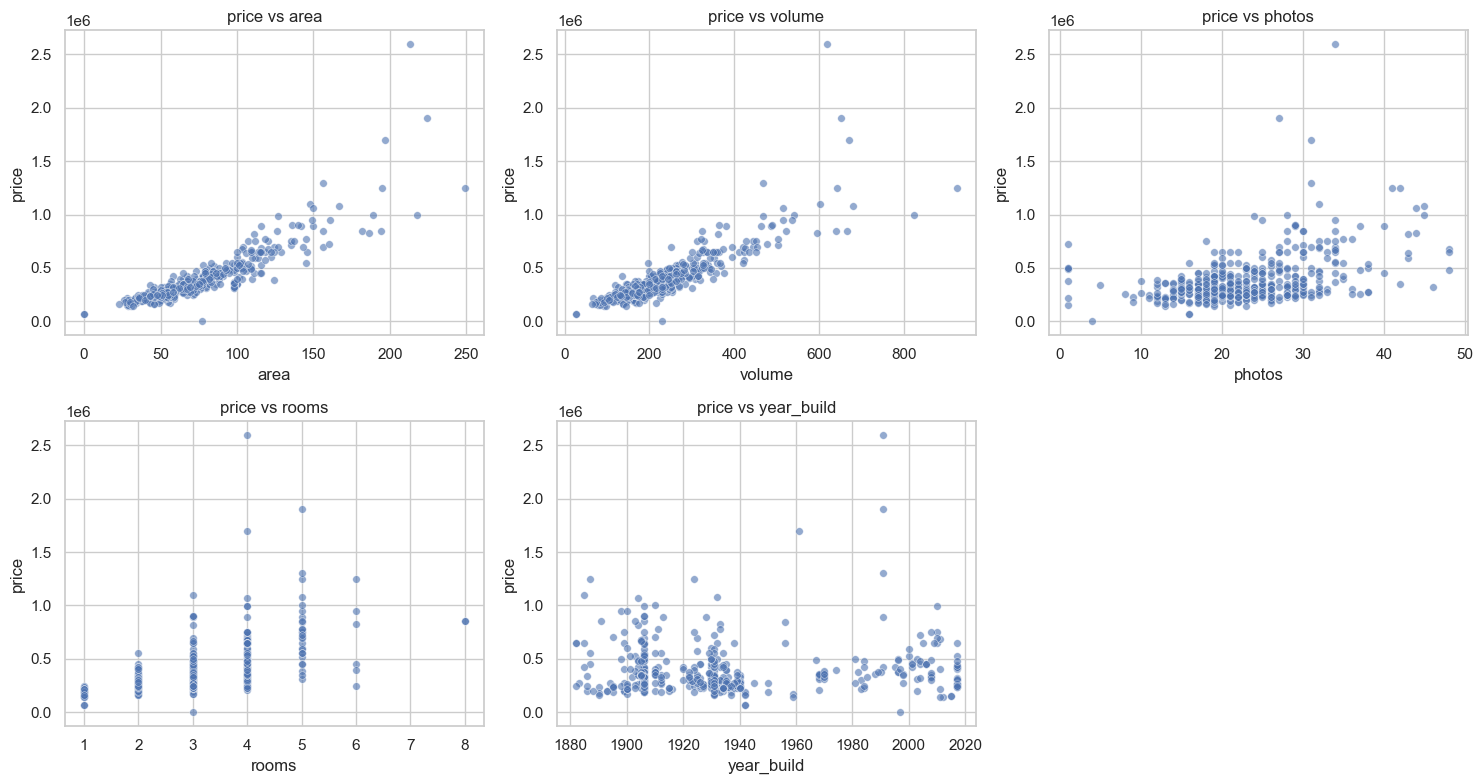

Pearson r with price:
area          0.887035
volume        0.865739
rooms         0.579646
photos        0.443967
year_build    0.052059
Name: price, dtype: float64
Selected for model: ['area', 'volume', 'rooms', 'photos']


In [8]:
# 2.1 a-b-c: scatterplots + Pearson r
num_candidates = ['area','volume','photos','rooms','year_build']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, c in enumerate(num_candidates):
    sns.scatterplot(data=segment, x=c, y='price', alpha=0.6, s=30, ax=axes[i])
    axes[i].set_title(f'price vs {c}')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

pearson = segment[['price'] + num_candidates].corr(numeric_only=True)['price'].drop('price').sort_values(key=np.abs, ascending=False)
print('Pearson r with price:')
print(pearson)

selected_features = ['area','volume','rooms','photos']
print('Selected for model:', selected_features)

In [9]:
# 2.1 d-e-f: fill missing, clean incorrect values, handle outliers
clean = segment.copy()

# fill missing numeric values with median
for c in ['price','area','volume','floors','year_build','photos','rooms','has_garden']:
    clean[c] = clean[c].fillna(clean[c].median())

# simple rule-based cleaning
clean = clean[(clean['price'] > 0) & (clean['area'] > 10) & (clean['volume'] > 10)]
clean = clean[(clean['rooms'] >= 1) & (clean['rooms'] <= 20)]
clean = clean[(clean['year_build'] >= 1600) & (clean['year_build'] <= 2025)]

# outlier filtering on core modeling variables + target
keep_cols = ['price','area','volume','rooms']
mask = pd.Series(True, index=clean.index)
outlier_limits = {}
for c in keep_cols:
    q1, q3 = clean[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo = q1 - 1.5*iqr
    hi = q3 + 1.5*iqr
    outlier_limits[c] = (float(lo), float(hi))
    mask &= clean[c].between(lo, hi)

model_df = clean[mask].copy()
print('Rows before cleaning:', len(segment))
print('Rows after cleaning:', len(clean))
print('Rows used for model:', len(model_df))
print('Outlier limits:', outlier_limits)

model_df.head()

Rows before cleaning: 475
Rows after cleaning: 472
Rows used for model: 431
Outlier limits: {'price': (-35000.0, 725000.0), 'area': (-6.0, 146.0), 'volume': (0.125, 423.125), 'rooms': (-1.0, 7.0)}


,postalcode,street,lat,lng,price,area,volume,floors,year_build,has_garden,type,photos,rooms,postcode4,stadsdeel,price_category
9,1057 PT Amsterdam,Van Kinsbergenstraat 88,0.523687,4.858506,400000,73,235,1,2011,0,appartement,35,3,1057,West,mid-high
10,1054 ZH Amsterdam,Jacob van Lennepkade 71 H,5.236544,4.873928,700000,104,252,4,1895,1,appartement,34,4,1054,West,high
15,1052 VL Amsterdam,Gillis van Ledenberchstraat 128 I,0.523754,0.487117,325000,60,180,5,1931,0,appartement,26,3,1052,West,mid-high
20,1058 GD Amsterdam,Andreasplein 34,5.235684,0.484521,650000,115,364,1,2010,1,appartement,21,4,1058,West,high
31,1055 RZ Amsterdam,Nieuwpoortstraat 86 D8,5.238435,4.858146,525000,116,338,2,2017,1,appartement,20,3,1055,West,high


## Exercise 2.2

In [10]:
# 2.2 a-b: regression models
X = model_df[selected_features]
y = model_df['price']

cv = KFold(n_splits=5, shuffle=True, random_state=42)

reg_models = {
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=300, random_state=42),
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=42)
}

reg_results = []
for name, m in reg_models.items():
    scores = cross_validate(
        m, X, y, cv=cv,
        scoring={'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}
    )
    reg_results.append({
        'model': name,
        'RMSE_cv_mean': -scores['test_rmse'].mean(),
        'R2_cv_mean': scores['test_r2'].mean()
    })

reg_results_df = pd.DataFrame(reg_results).sort_values('RMSE_cv_mean')
display(reg_results_df)

lin = LinearRegression().fit(X, y)
coef = pd.Series(lin.coef_, index=selected_features)
print('Linear formula:')
print('price =', round(lin.intercept_,2), '+', ' + '.join([f'({round(v,2)}*{k})' for k,v in coef.items()]))
print('Coefficients:')
print(coef.sort_values(ascending=False))

,model,RMSE_cv_mean,R2_cv_mean
2,GradientBoostingRegressor,50897.848810,0.801483
1,RandomForestRegressor,51378.616832,0.797867
0,LinearRegression,53277.626845,0.784587


Linear formula:
price = 19456.54 + (3709.64*area) + (334.99*volume) + (-8887.67*rooms) + (1092.88*photos)
Coefficients:
area      3709.641438
photos    1092.882646
volume     334.985020
rooms    -8887.666437
dtype: float64


In [11]:
best_reg = reg_results_df.iloc[0]['model']
print('Best regression model by lowest CV RMSE:', best_reg)
print('Metric used: RMSE, because target is euro price and error is easy to interpret in euros.')

Best regression model by lowest CV RMSE: GradientBoostingRegressor
Metric used: RMSE, because target is euro price and error is easy to interpret in euros.


## Exercise 3.1

In [12]:
# 3.1 a: general classification model
clf_df = model_df.copy()
q1, q2, q3 = clf_df['price'].quantile([0.25, 0.50, 0.75])
clf_df['price_category'] = pd.cut(clf_df['price'], bins=[-np.inf,q1,q2,q3,np.inf], labels=['low','mid-low','mid-high','high'])

Xc = clf_df[selected_features]
yc = clf_df['price_category']

classifiers = {
    'LogisticRegression': LogisticRegression(max_iter=3000),
    'RandomForestClassifier': RandomForestClassifier(n_estimators=400, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=9),
    'SVM_RBF': SVC(kernel='rbf', C=3, gamma='scale', random_state=42)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf_results = []
for name, model in classifiers.items():
    sc = cross_validate(model, Xc, yc, cv=skf, scoring={'acc':'accuracy','f1m':'f1_macro'})
    clf_results.append({
        'classifier': name,
        'Accuracy_cv_mean': sc['test_acc'].mean(),
        'F1_macro_cv_mean': sc['test_f1m'].mean()
    })

clf_results_df = pd.DataFrame(clf_results).sort_values('F1_macro_cv_mean', ascending=False)
display(clf_results_df)
print('Classifiers tested:', list(classifiers.keys()))
print('Chosen main classifier:', clf_results_df.iloc[0]['classifier'])
print('Main measure: F1-macro (balanced quality across all price classes).')

,classifier,Accuracy_cv_mean,F1_macro_cv_mean
1,RandomForestClassifier,0.642743,0.641320
3,SVM_RBF,0.624031,0.625391
0,LogisticRegression,0.628816,0.625157
2,KNN,0.631195,0.621935


Classifiers tested: ['LogisticRegression', 'RandomForestClassifier', 'KNN', 'SVM_RBF']
Chosen main classifier: RandomForestClassifier
Main measure: F1-macro (balanced quality across all price classes).


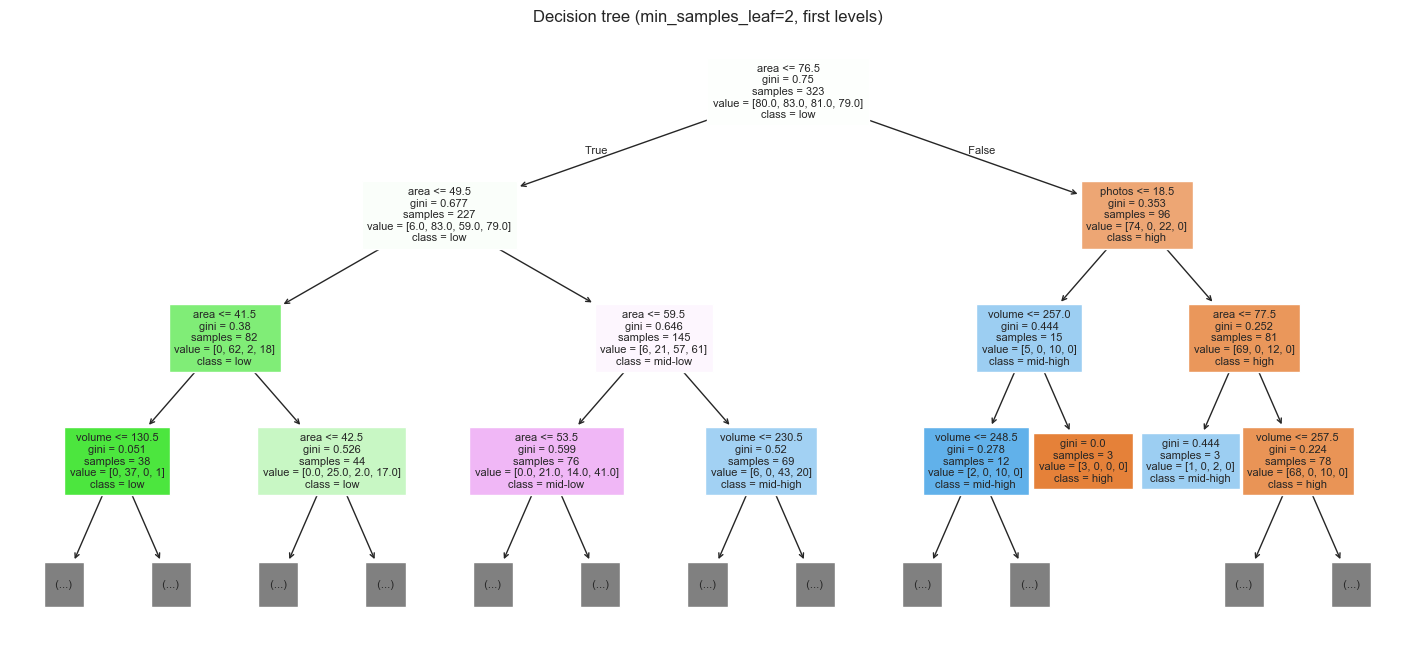

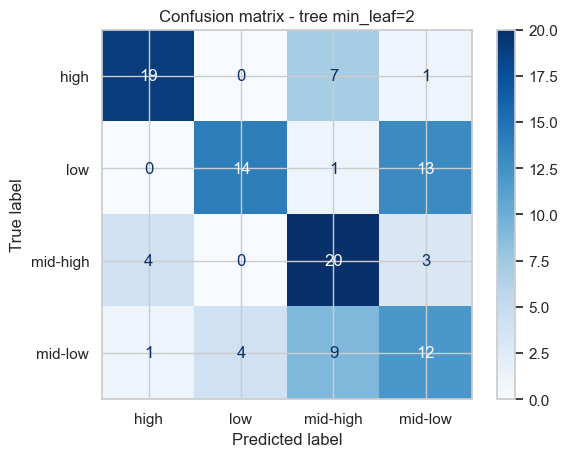

Tree min_leaf=2 accuracy: 0.6018518518518519
Accuracy by formula (TP+...)/N: 0.6018518518518519
Useful variables in tree: area      0.648152
volume    0.176188
photos    0.146745
rooms     0.028915
dtype: float64


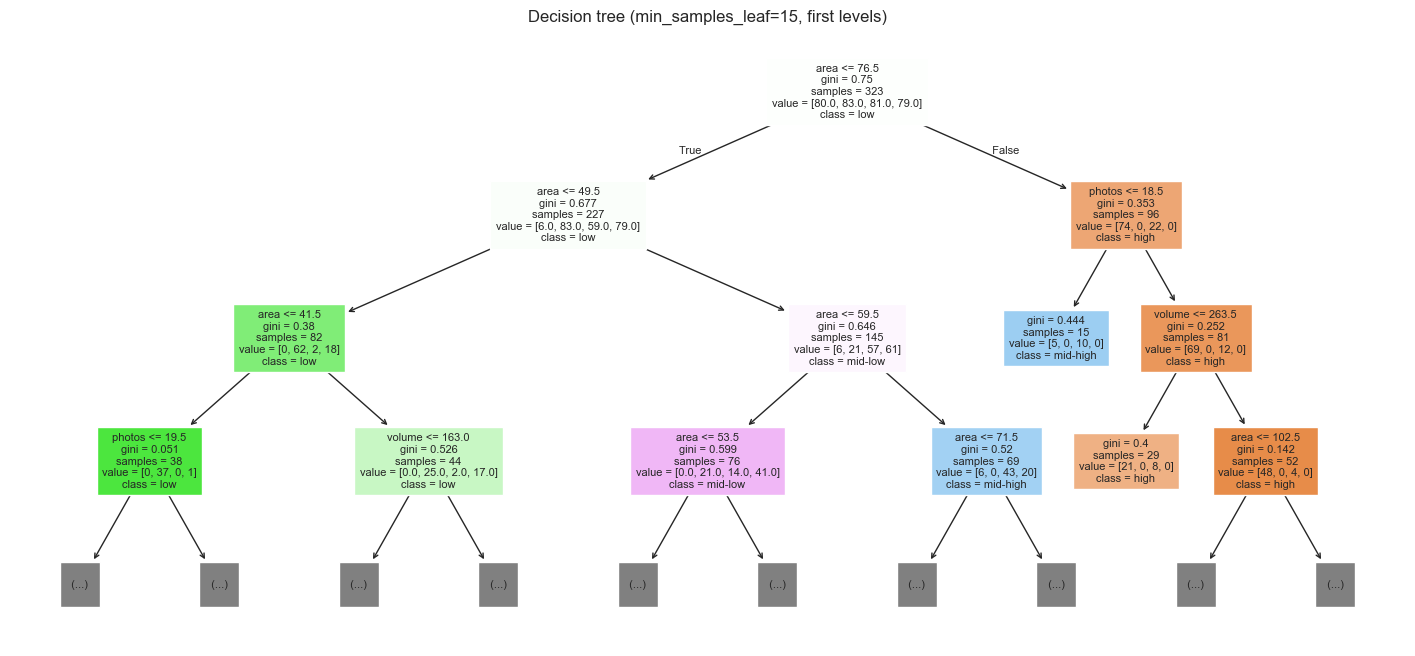

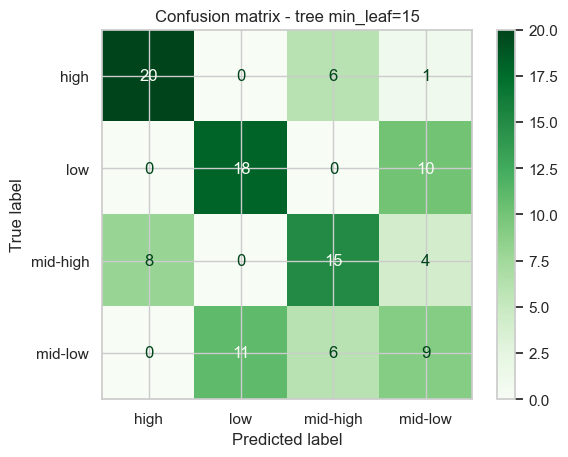

Tree min_leaf=15 accuracy: 0.5740740740740741
Difference in accuracy: -0.02777777777777779
Observation: larger min leaf gives a simpler tree, usually less overfitting but also lower detail.


In [13]:
# 3.1 b: decision tree default and min_samples_leaf=15
X_train, X_test, y_train, y_test = train_test_split(Xc, yc, test_size=0.25, random_state=42, stratify=yc)

tree1 = DecisionTreeClassifier(random_state=42, min_samples_leaf=2)
tree1.fit(X_train, y_train)
pred1 = tree1.predict(X_test)
acc1 = accuracy_score(y_test, pred1)
cm1 = confusion_matrix(y_test, pred1, labels=tree1.classes_)

plt.figure(figsize=(18,8))
plot_tree(tree1, feature_names=selected_features, class_names=[str(c) for c in tree1.classes_], filled=True, max_depth=3, fontsize=8)
plt.title('Decision tree (min_samples_leaf=2, first levels)')
plt.show()

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=tree1.classes_)
disp1.plot(cmap='Blues')
plt.title('Confusion matrix - tree min_leaf=2')
plt.show()

manual_acc1 = np.trace(cm1)/cm1.sum()
print('Tree min_leaf=2 accuracy:', acc1)
print('Accuracy by formula (TP+...)/N:', manual_acc1)
print('Useful variables in tree:', pd.Series(tree1.feature_importances_, index=selected_features).sort_values(ascending=False))

tree2 = DecisionTreeClassifier(random_state=42, min_samples_leaf=15)
tree2.fit(X_train, y_train)
pred2 = tree2.predict(X_test)
acc2 = accuracy_score(y_test, pred2)
cm2 = confusion_matrix(y_test, pred2, labels=tree2.classes_)

plt.figure(figsize=(18,8))
plot_tree(tree2, feature_names=selected_features, class_names=[str(c) for c in tree2.classes_], filled=True, max_depth=3, fontsize=8)
plt.title('Decision tree (min_samples_leaf=15, first levels)')
plt.show()

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=tree2.classes_)
disp2.plot(cmap='Greens')
plt.title('Confusion matrix - tree min_leaf=15')
plt.show()

print('Tree min_leaf=15 accuracy:', acc2)
print('Difference in accuracy:', acc2 - acc1)
print('Observation: larger min leaf gives a simpler tree, usually less overfitting but also lower detail.')

## Exercise 3.2

In [14]:
# 3.2 a: clean timeline dataset and keep needed series
import csv

rows = []
with open(TIME_PATH, 'r', encoding='utf-8', errors='replace') as f:
    for r in csv.reader(f, delimiter=';'):
        rows.append(r)

max_cols = max(len(r) for r in rows)
rows = [r + ['']*(max_cols-len(r)) for r in rows]
raw = pd.DataFrame(rows)

hdr_subject = raw.iloc[1].fillna('')
hdr_area = raw.iloc[2].fillna('')
hdr_unit = raw.iloc[3].fillna('')

cols = []
for i in range(max_cols):
    parts = [str(hdr_subject[i]).strip(), str(hdr_area[i]).strip(), str(hdr_unit[i]).strip()]
    parts = [p for p in parts if p]
    cols.append(' | '.join(parts))

data = raw.iloc[4:].copy().reset_index(drop=True)
data.columns = cols

df_time = data.copy()
df_time = df_time.rename(columns={df_time.columns[0]: 'Period'})

target_col = None
for c in df_time.columns:
    if 'Average selling price' in c and 'Amsterdam' in c:
        target_col = c
        break

ts = df_time[['Period', target_col]].copy()
ts.columns = ['Period', 'avg_price']
ts['avg_price'] = pd.to_numeric(ts['avg_price'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False), errors='coerce')
ts = ts.dropna(subset=['avg_price']).copy()

qmap = {'1st quarter': 'Q1', '2nd quarter': 'Q2', '3rd quarter': 'Q3', '4th quarter': 'Q4'}
def parse_period(p):
    p = str(p).strip()
    for k,v in qmap.items():
        if k in p:
            year = int(p.split()[0])
            return pd.Period(f'{year}-{v}', freq='Q').to_timestamp(how='end')
    return pd.NaT

ts['date'] = ts['Period'].map(parse_period)
ts = ts.dropna(subset=['date']).sort_values('date').reset_index(drop=True)
ts = ts[['date', 'avg_price']]
ts.tail()

,date,avg_price
101,2020-06-30 23:59:59.999999999,495498
102,2020-09-30 23:59:59.999999999,516930
103,2020-12-31 23:59:59.999999999,513031
104,2021-03-31 23:59:59.999999999,546838
105,2021-06-30 23:59:59.999999999,541324


In [15]:
# 3.2 b-c: moving average, exponential smoothing, Holt, ARIMA
train = ts[ts['date'] <= pd.Timestamp('2020-12-31')].copy()
test = ts[(ts['date'] > pd.Timestamp('2020-12-31')) & (ts['date'] <= pd.Timestamp('2021-06-30'))].copy()

train_s = train.set_index('date')['avg_price']
test_s = test.set_index('date')['avg_price']

def rmse(a,b):
    return float(np.sqrt(mean_squared_error(a,b)))

def mape(a,b):
    return float(mean_absolute_percentage_error(a,b))

results_ts = []

# Moving average
best_ma = None
for w in [2,3,4,5]:
    hist = train_s.copy().tolist()
    preds = []
    for y in test_s:
        p = np.mean(hist[-w:])
        preds.append(p)
        hist.append(y)
    e_rmse = rmse(test_s.values, preds)
    e_mape = mape(test_s.values, preds)
    results_ts.append({'model':'MovingAverage','params':f'window={w}','RMSE':e_rmse,'MAPE':e_mape})
    if best_ma is None or e_rmse < best_ma[0]:
        best_ma = (e_rmse, w)

# Simple exponential smoothing
best_es = None
for a in [0.2,0.4,0.6,0.8]:
    fit = SimpleExpSmoothing(train_s).fit(smoothing_level=a, optimized=False)
    pred = fit.forecast(len(test_s))
    e_rmse = rmse(test_s.values, pred.values)
    e_mape = mape(test_s.values, pred.values)
    results_ts.append({'model':'ExpSmoothing','params':f'alpha={a}','RMSE':e_rmse,'MAPE':e_mape})
    if best_es is None or e_rmse < best_es[0]:
        best_es = (e_rmse, a)

# Holt
best_holt = None
for a in [0.2,0.4,0.6,0.8]:
    for b in [0.1,0.2,0.3,0.4]:
        fit = Holt(train_s).fit(smoothing_level=a, smoothing_trend=b, optimized=False)
        pred = fit.forecast(len(test_s))
        e_rmse = rmse(test_s.values, pred.values)
        e_mape = mape(test_s.values, pred.values)
        results_ts.append({'model':'Holt','params':f'alpha={a},beta={b}','RMSE':e_rmse,'MAPE':e_mape})
        if best_holt is None or e_rmse < best_holt[0]:
            best_holt = (e_rmse, a, b)

# ARIMA
best_arima = None
for p in [0,1,2]:
    for d in [0,1,2]:
        for q in [0,1,2]:
            try:
                fit = ARIMA(train_s, order=(p,d,q)).fit()
                pred = fit.forecast(len(test_s))
                e_rmse = rmse(test_s.values, pred.values)
                e_mape = mape(test_s.values, pred.values)
                results_ts.append({'model':'ARIMA','params':f'({p},{d},{q})','RMSE':e_rmse,'MAPE':e_mape})
                if best_arima is None or e_rmse < best_arima[0]:
                    best_arima = (e_rmse, p, d, q)
            except Exception:
                pass

res_ts = pd.DataFrame(results_ts).sort_values('RMSE')
display(res_ts.head(12))

print('Best MA window:', best_ma[1])
print('Best ES alpha:', best_es[1])
print('Best Holt alpha,beta:', best_holt[1], best_holt[2])
print('Best ARIMA order:', (best_arima[1], best_arima[2], best_arima[3]))

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-

,model,params,RMSE,MAPE
41,ARIMA,"(1,2,2)",11137.527985,0.018884
50,ARIMA,"(2,2,2)",12061.472299,0.019760
12,Holt,"alpha=0.4,beta=0.1",12723.626043,0.024040
31,ARIMA,"(0,2,1)",12798.216905,0.024106
49,ARIMA,"(2,2,1)",12955.259933,0.021681
16,Holt,"alpha=0.6,beta=0.1",13142.852800,0.024185
20,Holt,"alpha=0.8,beta=0.1",13203.055765,0.024201
13,Holt,"alpha=0.4,beta=0.2",13673.394756,0.025219
21,Holt,"alpha=0.8,beta=0.2",13919.512957,0.024798
17,Holt,"alpha=0.6,beta=0.2",14243.175638,0.025037


Best MA window: 2
Best ES alpha: 0.8
Best Holt alpha,beta: 0.4 0.1
Best ARIMA order: (1, 2, 2)


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-

,Model,Params,RMSE,MAPE
3,ARIMA,"(1,2,2)",11137.527985,0.018884
2,Holt,"alpha=0.4,beta=0.1",12723.626043,0.024040
0,MovingAverage,window=2,23036.620794,0.035773
1,ExpSmoothing,alpha=0.8,23778.166604,0.030922


Chosen final forecasting model: ARIMA


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)


,quarter,forecast_avg_price
0,2021 Q3,558024
1,2021 Q4,558896


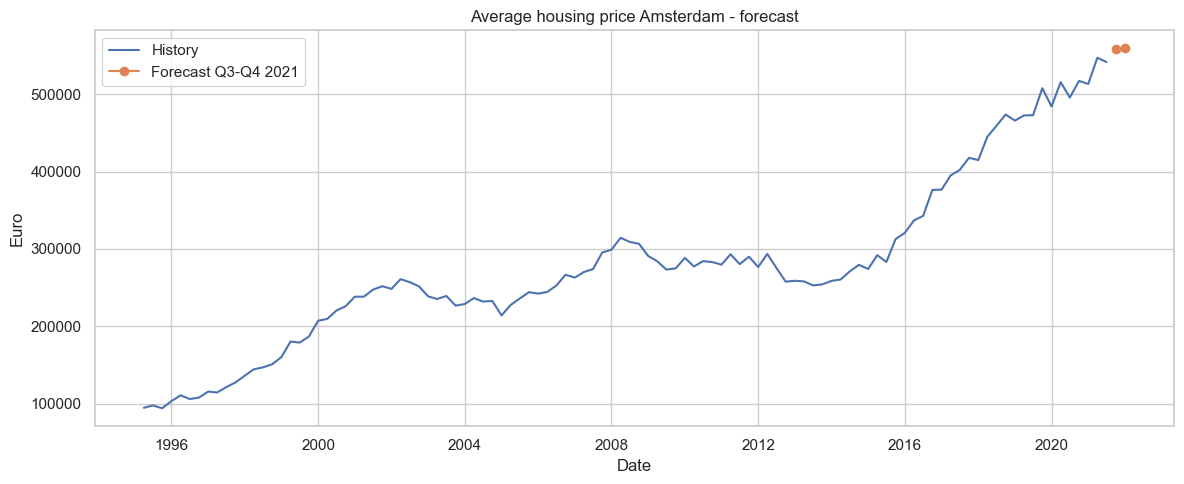

In [16]:
# 3.2 d-e: compare best 4 and forecast 2021 Q3/Q4
best_table = []

# MA best
w = best_ma[1]
hist = train_s.copy().tolist()
pred_ma = []
for y in test_s:
    p = np.mean(hist[-w:])
    pred_ma.append(p)
    hist.append(y)
best_table.append({'Model':'MovingAverage','Params':f'window={w}','RMSE':rmse(test_s.values,pred_ma),'MAPE':mape(test_s.values,pred_ma)})

# ES best
a = best_es[1]
fit_es = SimpleExpSmoothing(train_s).fit(smoothing_level=a, optimized=False)
pred_es = fit_es.forecast(len(test_s))
best_table.append({'Model':'ExpSmoothing','Params':f'alpha={a}','RMSE':rmse(test_s.values,pred_es.values),'MAPE':mape(test_s.values,pred_es.values)})

# Holt best
a,b = best_holt[1], best_holt[2]
fit_h = Holt(train_s).fit(smoothing_level=a, smoothing_trend=b, optimized=False)
pred_h = fit_h.forecast(len(test_s))
best_table.append({'Model':'Holt','Params':f'alpha={a},beta={b}','RMSE':rmse(test_s.values,pred_h.values),'MAPE':mape(test_s.values,pred_h.values)})

# ARIMA best
p,d,q = best_arima[1], best_arima[2], best_arima[3]
fit_a = ARIMA(train_s, order=(p,d,q)).fit()
pred_a = fit_a.forecast(len(test_s))
best_table.append({'Model':'ARIMA','Params':f'({p},{d},{q})','RMSE':rmse(test_s.values,pred_a.values),'MAPE':mape(test_s.values,pred_a.values)})

best_table = pd.DataFrame(best_table).sort_values('RMSE')
display(best_table)

best_model = best_table.iloc[0]['Model']
print('Chosen final forecasting model:', best_model)

full_s = ts.set_index('date')['avg_price']
future_idx = pd.period_range('2021Q3','2021Q4',freq='Q').to_timestamp(how='end')

if best_model == 'MovingAverage':
    hist = full_s.tolist()
    fvals = []
    for _ in range(2):
        pval = float(np.mean(hist[-w:]))
        fvals.append(pval)
        hist.append(pval)
    fc = pd.Series(fvals, index=future_idx)
elif best_model == 'ExpSmoothing':
    fit = SimpleExpSmoothing(full_s).fit(smoothing_level=a, optimized=False)
    fc = fit.forecast(2)
    fc.index = future_idx
elif best_model == 'Holt':
    fit = Holt(full_s).fit(smoothing_level=a, smoothing_trend=b, optimized=False)
    fc = fit.forecast(2)
    fc.index = future_idx
else:
    fit = ARIMA(full_s, order=(p,d,q)).fit()
    fc = fit.forecast(2)
    fc.index = future_idx

forecast_df = pd.DataFrame({'date': fc.index, 'forecast_avg_price': fc.values})
forecast_df['quarter'] = ['2021 Q3','2021 Q4']
forecast_df = forecast_df[['quarter','forecast_avg_price']]
forecast_df['forecast_avg_price'] = forecast_df['forecast_avg_price'].round(0).astype(int)
display(forecast_df)

plt.figure(figsize=(12,5))
plt.plot(ts['date'], ts['avg_price'], label='History')
plt.plot(fc.index, fc.values, marker='o', label='Forecast Q3-Q4 2021')
plt.title('Average housing price Amsterdam - forecast')
plt.xlabel('Date')
plt.ylabel('Euro')
plt.legend()
plt.tight_layout()
plt.show()

Done.